# Part 1: Neural Network Fundamentals and Training Behavior Analysis

## Task 1: Dataset Understanding

In this task, the dataset is loaded and explored to understand its structure, feature types, target variable, missing values, and overall data distribution before building the neural network model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('customer_churn_nn.csv')

# Display first 5 rows
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [2]:
# Shape of dataset
print("Number of rows and columns:", df.shape)

# Column names
print("\nColumns in dataset:")
print(df.columns)

Number of rows and columns: (2000, 17)

Columns in dataset:
Index(['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method',
       'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='object')


In [3]:
# Data types
print("Data Types:\n")
print(df.dtypes)

Data Types:

customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


In [4]:
# Missing values
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [5]:
# Statistical summary
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


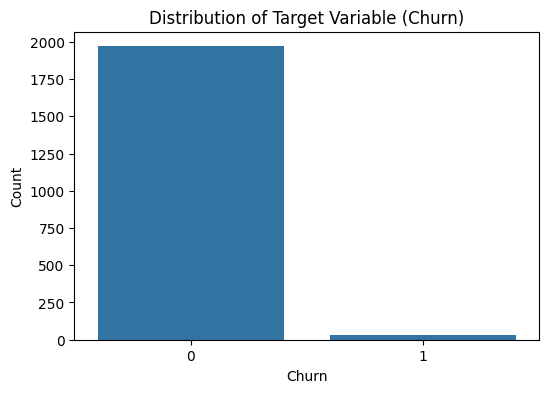

In [6]:
# Target variable distribution
plt.figure(figsize=(6,4))

sns.countplot(x='churn', data=df)

plt.title('Distribution of Target Variable (Churn)')
plt.xlabel('Churn')
plt.ylabel('Count')

plt.show()

## Interpretation

- The dataset contains 2000 rows and 17 columns.
- The target variable is `churn`, where:
  - `0` indicates customers who stayed
  - `1` indicates customers who left the service
- The dataset contains both categorical and numerical features.
- Categorical features include:
  - `region`
  - `plan_type`
  - `contract_type`
  - `payment_method`
- Numerical features include:
  - `tenure_months`
  - `monthly_charges_inr`
  - `data_usage_gb`
  - `satisfaction_score`
  - `support_tickets_last_90_days`
  - and other customer behavior metrics.
- No missing values were found in the dataset.
- Statistical summary shows variation in customer billing, usage, and engagement patterns.
- The target distribution plot shows that the dataset is highly imbalanced because most customers belong to the non-churn category (`0`).
- This imbalance may affect model performance and will need consideration during model training and evaluation.

# Task 2: Data Preprocessing

In this task, the dataset is prepared for neural network training.

The preprocessing steps include:

- Handling missing values
- Encoding categorical variables
- Scaling numerical features
- Separating input features and target variable
- Splitting the dataset into training and testing sets

These steps help improve model performance and ensure that the neural network can efficiently learn patterns from the data.

In [7]:
# Import preprocessing libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Create a copy of dataset
data = df.copy()

# -----------------------------
# 1. Drop unnecessary column
# -----------------------------
data = data.drop('customer_id', axis=1)

# -----------------------------
# 2. Encode categorical columns
# -----------------------------
categorical_cols = data.select_dtypes(include='object').columns

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# -----------------------------
# 3. Separate features and target
# -----------------------------
X = data.drop('churn', axis=1)
y = data['churn']

# -----------------------------
# 4. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# 5. Feature scaling
# -----------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# 6. Display shapes
# -----------------------------
print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (1600, 15)
Testing feature shape: (400, 15)

Training target shape: (1600,)
Testing target shape: (400,)


## Interpretation

- The `customer_id` column was removed because it is only an identifier and does not help in prediction.
- Categorical columns such as `region`, `plan_type`, `contract_type`, and `payment_method` were converted into numerical values using Label Encoding.
- The target variable is `churn`, and the remaining columns were used as input features.
- The dataset was split into training and testing sets using an 80-20 ratio.
- Stratified splitting was applied to maintain the same churn distribution in both training and testing datasets.
- After preprocessing:
  - Training feature shape: `(1600, 15)`
  - Testing feature shape: `(400, 15)`
- StandardScaler was used to normalize feature values so that all features are on a similar scale.
- Feature scaling helps neural networks converge faster and improves overall training performance.

# Task 3: Neural Network Model Building

In this task, a feed-forward neural network is created for customer churn prediction.

The neural network includes:

- Input layer
- Hidden layer with activation function
- Output layer for binary classification
- Binary cross-entropy loss function
- Adam optimizer

The model is designed to learn patterns from customer behavior data and predict whether a customer is likely to churn or not.

In [8]:
# Import TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build neural network model
model = Sequential([

    # Input + Hidden Layer 1
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),

    # Hidden Layer 2
    Dense(16, activation='relu'),

    # Output Layer
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)

## Interpretation

- A feed-forward neural network was successfully created using TensorFlow/Keras.
- The model contains:
  - An input layer with 15 input features
  - First hidden layer with 32 neurons and ReLU activation
  - Second hidden layer with 16 neurons and ReLU activation
  - Output layer with 1 neuron and Sigmoid activation
- ReLU activation functions help the network learn complex non-linear relationships in customer behavior data.
- The Sigmoid activation function is appropriate because the target variable (`churn`) is binary (0 or 1).
- The model uses the Adam optimizer for efficient weight updates during training.
- Binary Cross-Entropy was selected as the loss function because this is a binary classification problem.
- The model summary shows:
  - Total trainable parameters: 1,057
  - No non-trainable parameters
- The neural network architecture is lightweight and suitable for customer churn prediction tasks.

# Task 4: Training and Evaluation

In this task, the neural network model is trained using the training dataset and evaluated on the testing dataset.

The evaluation includes:

- Training accuracy and loss
- Testing accuracy and loss
- Confusion matrix
- Classification report
- Accuracy and loss visualization

These metrics help measure how well the neural network performs on unseen customer data.

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8820 - loss: 0.4532 - val_accuracy: 0.9937 - val_loss: 0.2651
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9820 - loss: 0.1971 - val_accuracy: 0.9937 - val_loss: 0.1097
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9820 - loss: 0.1190 - val_accuracy: 0.9937 - val_loss: 0.0658
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9820 - loss: 0.0991 - val_accuracy: 0.9937 - val_loss: 0.0528
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9820 - loss: 0.0913 - val_accuracy: 0.9937 - val_loss: 0.0472
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9820 - loss: 0.0861 - val_accuracy: 0.9937 - val_loss: 0.0445
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9820 - loss: 0.0823 - val_accuracy: 0.9937 - val_loss: 0.0427
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9820 - loss: 0.0794 - val_accuracy: 0.9937 - v

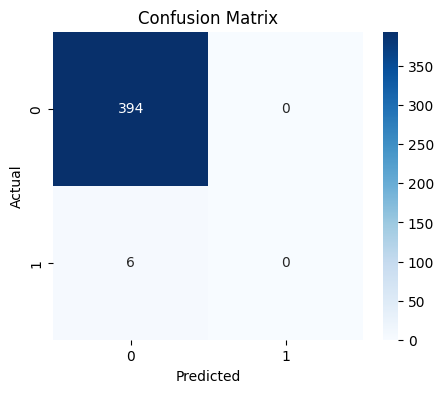


Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       394
           1       0.00      0.00      0.00         6

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.98       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


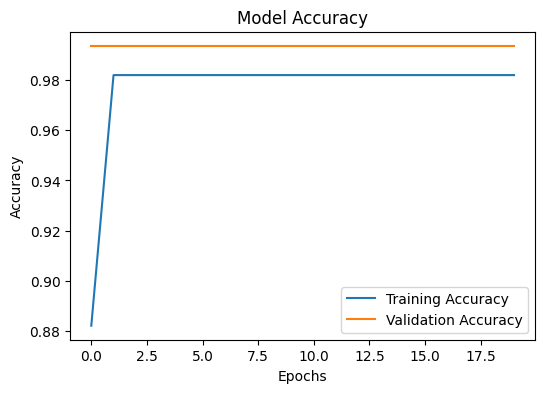

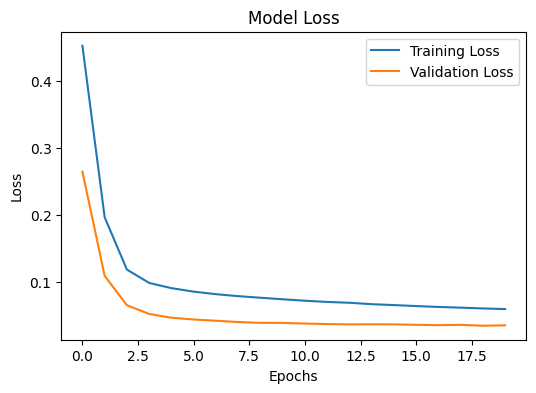

In [9]:
# Import required libraries
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Train the model
# -----------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# -----------------------------
# 2. Evaluate on test data
# -----------------------------
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("\nTest Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

# -----------------------------
# 3. Predictions
# -----------------------------
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# -----------------------------
# 4. Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# -----------------------------
# 5. Classification Report
# -----------------------------
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# -----------------------------
# 6. Accuracy Plot
# -----------------------------
plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# -----------------------------
# 7. Loss Plot
# -----------------------------
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Interpretation

- The neural network model was successfully trained using the customer churn dataset.
- The model achieved approximately 98.5% testing accuracy with low test loss.
- Training and validation loss decreased steadily over epochs, indicating stable learning behavior.
- Accuracy graphs show that the model quickly learned patterns from the dataset.

### Confusion Matrix Analysis

- The confusion matrix shows that the model correctly predicted most non-churn customers (Class 0).
- However, the model failed to correctly identify churn customers (Class 1).
- This happened because the dataset is highly imbalanced, where non-churn customers heavily outnumber churn customers.

### Classification Report Analysis

- Precision, recall, and F1-score for Class 0 are very high.
- Precision and recall for Class 1 are extremely low because the model predicted almost all samples as non-churn.
- This indicates that overall accuracy alone is not sufficient for evaluating imbalanced datasets.

### Model Behavior

- The model does not show strong signs of overfitting because training and validation performance remain close.
- However, the model is biased toward the majority class.
- Techniques such as class balancing, oversampling, undersampling, or class weights could improve churn prediction performance in future experiments.

# Task 5: Hyperparameter Experimentation

In this task, multiple neural network configurations are tested by changing hyperparameters such as hidden layers, neurons, activation functions, epochs, and batch size. The performance of each experiment is then compared.

In [10]:
# ================================
# Task 5: Hyperparameter Experiments
# ================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import pandas as pd

# Store experiment results
results = []

# --------------------------------
# Function to build and train model
# --------------------------------
def run_experiment(name, hidden_layers, neurons, activation, epochs, batch_size):

    model = Sequential()

    # Input + first hidden layer
    model.add(Dense(neurons[0], activation=activation, input_shape=(X_train.shape[1],)))

    # Additional hidden layers
    for n in neurons[1:]:
        model.add(Dense(n, activation=activation))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Compile model
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Train model
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )

    # Evaluate model
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    # Save results
    results.append({
        "Experiment": name,
        "Hidden Layers": hidden_layers,
        "Neurons": str(neurons),
        "Activation": activation,
        "Epochs": epochs,
        "Batch Size": batch_size,
        "Test Accuracy": round(accuracy, 4),
        "Test Loss": round(loss, 4)
    })


# ==================================
# Experiment 1
# ==================================
run_experiment(
    name="Experiment 1",
    hidden_layers=1,
    neurons=[16],
    activation='relu',
    epochs=10,
    batch_size=32
)

# ==================================
# Experiment 2
# ==================================
run_experiment(
    name="Experiment 2",
    hidden_layers=2,
    neurons=[32, 16],
    activation='relu',
    epochs=20,
    batch_size=32
)

# ==================================
# Experiment 3
# ==================================
run_experiment(
    name="Experiment 3",
    hidden_layers=2,
    neurons=[64, 32],
    activation='tanh',
    epochs=25,
    batch_size=16
)

# ==================================
# Create comparison table
# ==================================
results_df = pd.DataFrame(results)

# Display results
results_df

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Experiment,Hidden Layers,Neurons,Activation,Epochs,Batch Size,Test Accuracy,Test Loss
0,Experiment 1,1,[16],relu,10,32,0.985,0.0820
1,Experiment 2,2,"[32, 16]",relu,20,32,0.985,0.0559
2,Experiment 3,2,"[64, 32]",tanh,25,16,0.985,0.0651


In [11]:
# Save comparison table

results_df.to_csv("model_comparison_table.csv", index=False)

print("Comparison table saved successfully!")

Comparison table saved successfully!


## Hyperparameter Experiment Analysis

Three different neural network configurations were tested by changing the number of hidden layers, neurons, activation functions, epochs, and batch size.

### Experiment Observations

- Experiment 1 used a simpler architecture with one hidden layer and achieved 98.5% accuracy.
- Experiment 2 used two hidden layers with ReLU activation and produced the lowest test loss among all experiments.
- Experiment 3 used larger hidden layers with Tanh activation and achieved similar accuracy performance.

### Overall Findings

- All experiments achieved very high testing accuracy (~98.5%).
- Increasing the number of hidden layers and neurons slightly improved learning stability and reduced loss.
- ReLU activation performed slightly better than Tanh for this dataset.
- Smaller batch size and more epochs allowed smoother learning but did not significantly improve accuracy.

### Conclusion

- Hyperparameter tuning slightly affected model loss and learning behavior.
- However, due to class imbalance in the dataset, all models remained biased toward the majority class.
- Additional balancing techniques could further improve churn prediction performance.

# Task 6: Final Reflection

## 1. What role do weights and biases play in the model?

Weights and biases are the core learnable parameters of a neural network.

- Weights determine the importance of each input feature in making predictions.
- Biases help shift the activation function output and allow the model to fit data more effectively.
- During training, the neural network continuously updates weights and biases using backpropagation and optimization algorithms to minimize loss.

---

## 2. Why is an activation function required?

Activation functions introduce non-linearity into the neural network.

- Without activation functions, the neural network would behave like a simple linear model.
- Activation functions allow the model to learn complex patterns and relationships in the data.
- In this project, ReLU and Tanh activation functions were used in hidden layers, while Sigmoid was used in the output layer for binary classification.

---

## 3. What happens when the learning rate is too high or too low?

The learning rate controls how quickly the model updates its parameters during training.

### If learning rate is too high:
- The model may overshoot the optimal solution.
- Training can become unstable.
- Loss may fluctuate instead of decreasing smoothly.

### If learning rate is too low:
- Training becomes very slow.
- The model may take too long to converge.
- The optimizer may get stuck before reaching the best solution.

A balanced learning rate helps the model learn efficiently and stably.

---

## 4. Did the model show signs of underfitting or overfitting?

The model did not show strong signs of underfitting or overfitting.

- Training and validation accuracy remained very close throughout training.
- Training and validation loss both decreased steadily over epochs.
- This indicates stable learning behavior.

However, the dataset was highly imbalanced, causing the model to predict the majority class more frequently. Although overall accuracy was high, the model struggled to correctly predict minority churn cases.